<a href="https://colab.research.google.com/github/mbk-dev/okama/blob/master/examples/10%20forecasting.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>

In [1]:
%%capture --no-stderr
%pip install --quiet -U okama

In [2]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [12.0, 6.0]

import okama as ok

okama supports the following theoretical distributions for Monte Carlo forecasting:
- Normal (`"norm"`): parameters `(mu, sigma)`
- Lognormal (`"lognorm"`): parameters `(s, loc, scale)` in SciPy’s parameterization
- Student's t (`"t"`): parameters `(df, loc, scale)`

You can set the active distribution for a portfolio with `pf.dcf.set_mc_parameters(distribution=...)`. Parameters are estimated from historical data by default but can be overridden manually (see below).

### Testing distributions

Before using theoretical distributions, we should compare them with historical data to see how well they fit.  
There is a [notebook with examples](<08 backtesting distribution.ipynb>) dedicated to backtesting distributions.

### Simple forecasting

Let's create an equal-weighted strategy with stocks, bonds, and gold.

In [3]:
ls = ["SPY.US", "AGG.US", "GLD.US"]
weights = [0.50, 0.40, 0.10]
pf = ok.Portfolio(ls, ccy="USD", weights=weights, last_date="2025-11", inflation=True)
pf

symbol                              portfolio_2031.PF
assets                       [SPY.US, AGG.US, GLD.US]
weights                               [0.5, 0.4, 0.1]
rebalancing_period                              month
rebalancing_abs_deviation                        None
rebalancing_rel_deviation                        None
currency                                          USD
inflation                                    USD.INFL
first_date                                    2004-12
last_date                                     2025-11
period_length                      21 years, 0 months
dtype: object

In [4]:
pf.table

,asset name,ticker,weights
0,SPDR S&P 500 ETF Trust,SPY.US,0.5
1,iShares Core U.S. Aggregate Bond ETF,AGG.US,0.4
2,SPDR® Gold Shares,GLD.US,0.1


The most intuitive way to present forecasted portfolio performance is to use the `plot_forecast` method to draw an accumulated-return chart with historical and forecasted data.

It is also possible to use the default values: a 5-year forecast with a normal distribution and 100 random scenarios without cash flow.

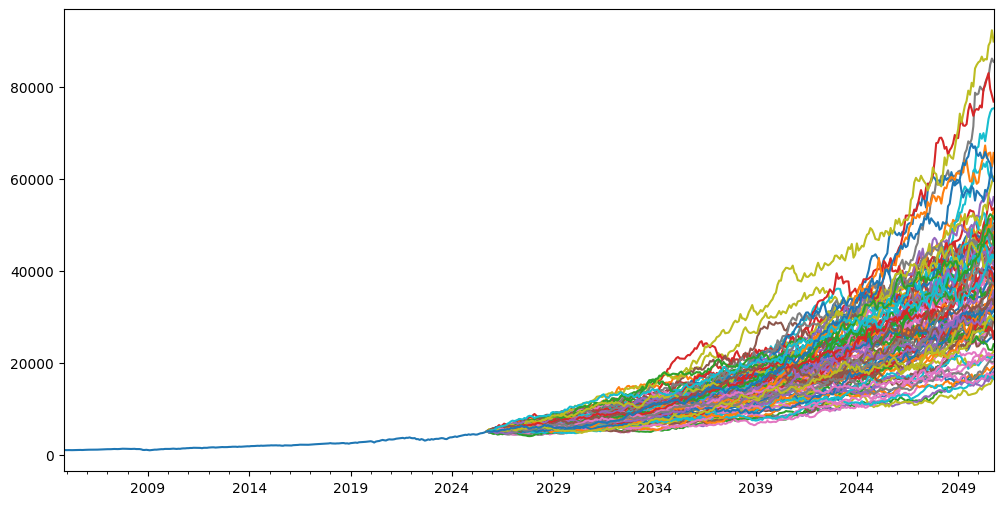

In [5]:
pf.dcf.plot_forecast_monte_carlo();

In [6]:
pf.dcf.cashflow_parameters

Strategy name                        fixed_amount
Portfolio symbol                portfolio_2031.PF
Cash flow initial investment               1000.0
Cash flow frequency                          none
Cash flow strategy                   fixed_amount
Cash flow amount                                0
Cash flow indexation                      0.02551
dtype: object

However, after backtesting the theoretical distributions, it is better to select the one that fits the data best.

In [7]:
pf.dcf.mc.kstest_for_all_distributions

,statistic,p-value
norm,0.070985,0.150347
lognorm,0.076248,0.101343
t,0.032953,0.938744


In this case, Student's t distribution is a better fit.  
The parameters of the theoretical distribution can be set automatically.

In [8]:
pf.dcf.mc.distribution = "t"
pf.dcf.mc.period = 10  # forecasting period (years)
pf.dcf.mc.mc_number = 200  # number of Monte Carlo random scenarios

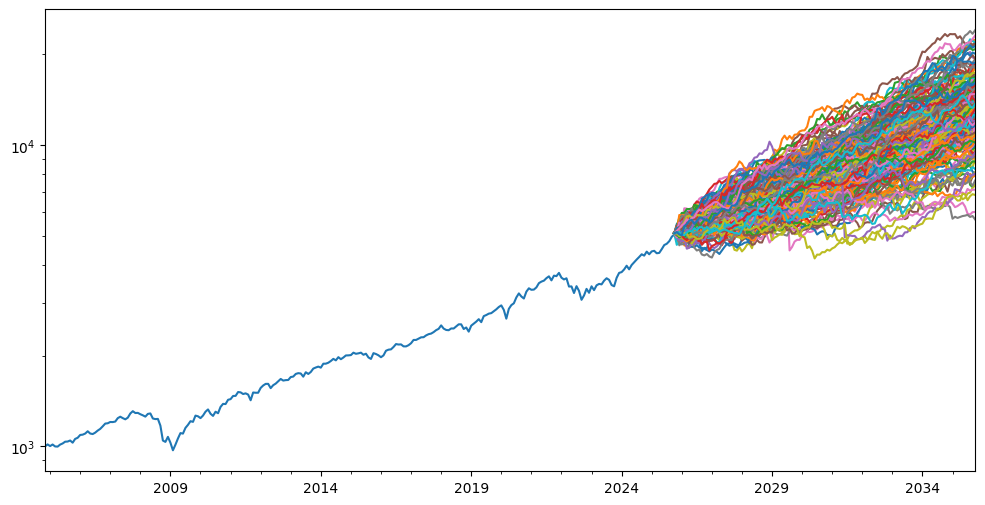

In [9]:
pf.dcf.plot_forecast_monte_carlo()
plt.yscale("log")  # log scale Y-axis

We can get numeric CAGR percentiles for the Monte Carlo scenario distribution with the `percentile_distribution_cagr` method.

In [10]:
pf.dcf.mc.percentile_distribution_cagr(percentiles=[1, 20, 50, 80, 99])

{1: np.float64(0.033288562730075896),
 20: np.float64(0.07372700127900891),
 50: np.float64(0.09764657486759465),
 80: np.float64(0.12149131677789296),
 99: np.float64(0.1588343645988907)}

The worst scenario is at the 1st percentile, while the most optimistic is at the 99th percentile.

It is also important to see performance expectations over short horizons such as 1 year.

In [11]:
pf.dcf.mc.period = 1

In [12]:
pf.dcf.mc.percentile_distribution_cagr(percentiles=[1, 20, 50, 80, 99])

{1: np.float64(-0.08136473805740344),
 20: np.float64(0.027337490418271052),
 50: np.float64(0.09430994566581152),
 80: np.float64(0.1816877468579125),
 99: np.float64(0.3325445316161842)}

The probability of getting a negative result over the forecast period is the percentile rank for a zero CAGR value (`score=0`).

In [13]:
pf.percentile_inverse_cagr(score=0)  # one year period

np.float64(12.863070539419088)

## Fat tails

When forecasting the results of investment strategies, one often has to rely on pessimistic expectations. Financial goals must be achieved even when things aren't going well.

Student's t distribution is useful for stress-testing strategies against extreme shortfalls. However, even this distribution may need manual adjustment to better match the 1st or 5th percentile outcomes.

The Q‑Q (quantile‑quantile) plot visualizes the quantiles of historical monthly portfolio returns against the quantiles of a chosen theoretical distribution. It is useful to see how well the theoretical distribution fits the data, especially in the left tail where risk lives.

Function: `pf.dcf.mc.plot_qq()`

Parameters:
- `var_level` (int, default 5): Confidence level for VaR and CVaR in percent. Used to mark empirical and theoretical VaR/CVaR levels.
- `bootstrap_size_var` (int, default 2000): Number of bootstrap resamples used to draw a confidence stripe for VaR/CVaR. Set to 0 to disable the bootstrap stripe.
- `zoom_to_left_tail` (int, default 20): Zoom the x-axis to [1, zoom_to_left_tail] percentiles. Use 99 to show the full 1–99% range.
- `figsize` (tuple, optional): Matplotlib figure size in inches.

Bootstrap bands are confidence bands built by repeatedly resampling the historical returns (bootstrap) and recomputing tail metrics such as VaR/CVaR; they quantify the uncertainty of the empirical left-tail estimates.

When we run `plot_qq` with the default Student's t setup, okama overlays the theoretical curve and reports the gap between theoretical and empirical 5% VaR/CVaR, along with bootstrap confidence bands. The plot below shows that the empirical left tail is heavier than the baseline Student's t assumption.

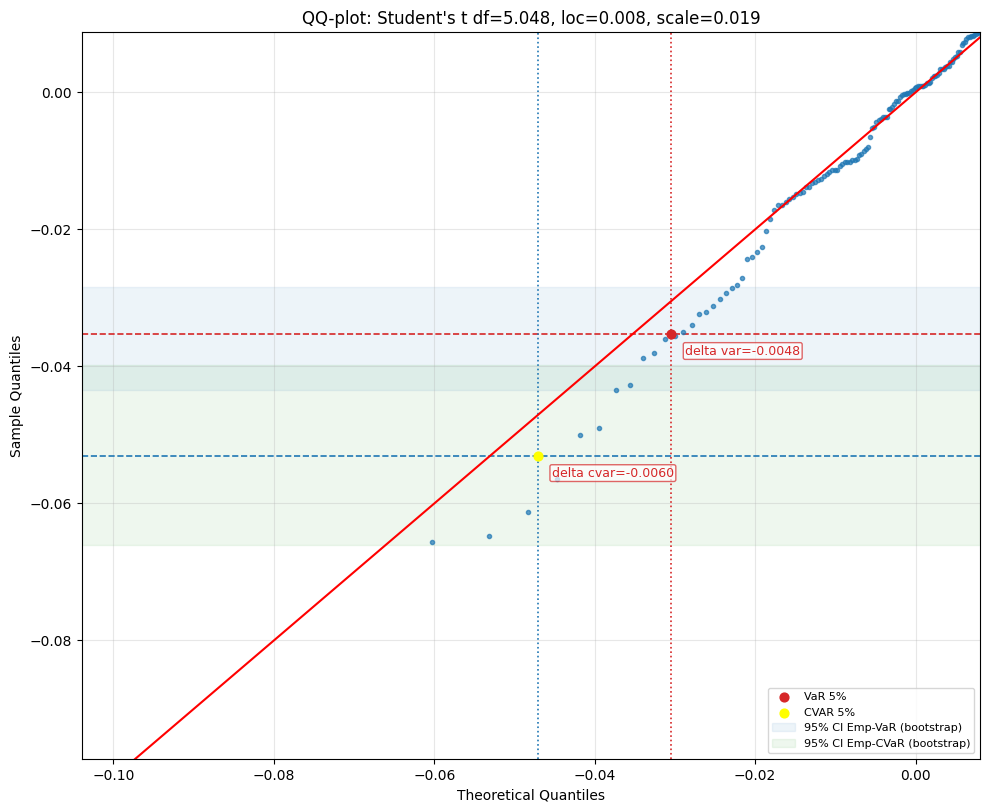

2026-03-28 21:04:25,694 - INFO - VaR  5%: theor=-0.030453, emp=-0.035220, delta(emp-theor)=-0.004767
2026-03-28 21:04:25,695 - INFO - CVAR 5%: theor=-0.047079, emp=-0.053042, delta(emp-theor)=-0.005964
2026-03-28 21:04:25,695 - INFO - 95% CI empiric VaR (bootstrap): [-0.043470, -0.028462]
2026-03-28 21:04:25,696 - INFO - 95% CI empiric CVaR (bootstrap): [-0.066081, -0.039789]


In [14]:
pf.dcf.mc.plot_qq(var_level=5, bootstrap_size_var=2000, zoom_to_left_tail=50, figsize=(10, 8));

Using `optimize_df_for_students(var_level=5)`, we let okama calibrate the degrees of freedom to better match the observed tail.

In [15]:
pf.dcf.mc.optimize_df_for_students(var_level=5)

3.9321343321484736

After setting `distribution_parameters` with that `df` and replotting, the Q-Q chart and VaR/CVaR diagnostics line up more closely, giving a pessimistic but data-driven view of extreme shortfalls.

In [16]:
pf.dcf.mc.distribution_parameters = (3.9, None, None)  # df, loc, scale

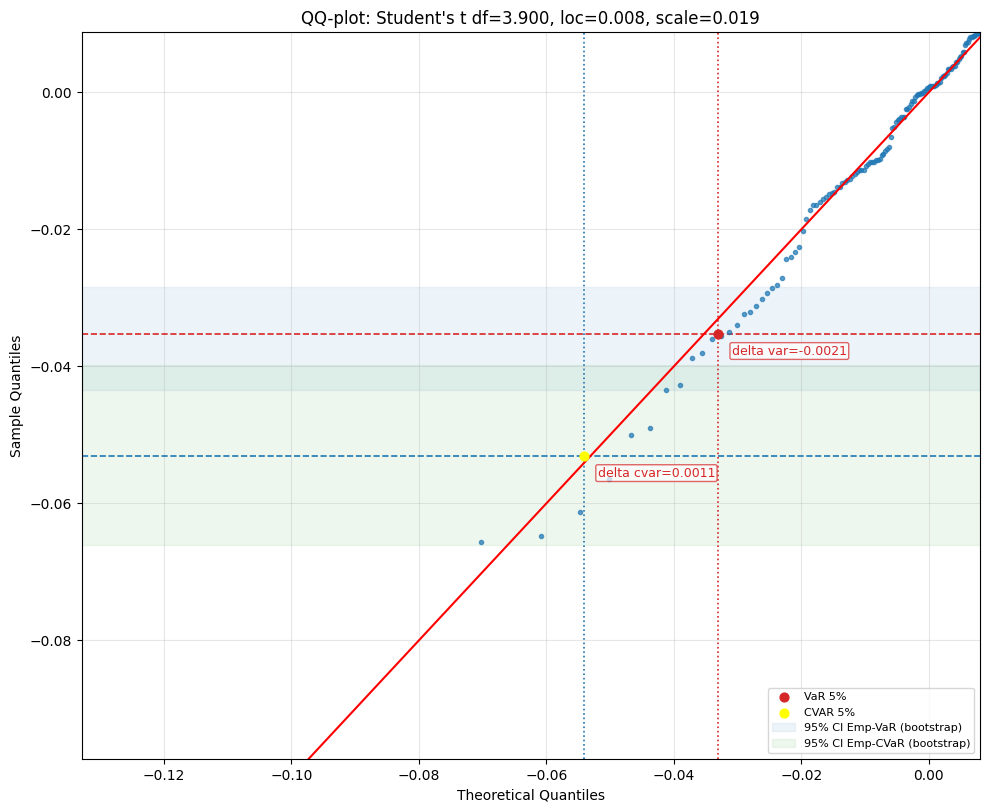

2026-03-28 21:04:26,040 - INFO - VaR  5%: theor=-0.033071, emp=-0.035220, delta(emp-theor)=-0.002148
2026-03-28 21:04:26,041 - INFO - CVAR 5%: theor=-0.054121, emp=-0.053042, delta(emp-theor)=0.001078
2026-03-28 21:04:26,041 - INFO - 95% CI empiric VaR (bootstrap): [-0.043470, -0.028462]
2026-03-28 21:04:26,041 - INFO - 95% CI empiric CVaR (bootstrap): [-0.066081, -0.039789]


In [17]:
pf.dcf.mc.plot_qq(var_level=5, bootstrap_size_var=2000, zoom_to_left_tail=50, figsize=(10, 8));

With this setup, we can forecast portfolio performance for the selected `var_level` (5).

In [18]:
pf.dcf.cashflow_parameters

Strategy name                        fixed_amount
Portfolio symbol                portfolio_2031.PF
Cash flow initial investment               1000.0
Cash flow frequency                          none
Cash flow strategy                   fixed_amount
Cash flow amount                                0
Cash flow indexation                      0.02551
dtype: object

Next, we will use the Monte Carlo method to forecast various strategy parameters.

In [19]:
pf.dcf.cashflow_parameters.initial_investment = 100_000  # Initial investment
pf.dcf.mc.period = 15  # forecasting period (years)

Let's plot the capital-growth chart for the strategy with the selected parameters. This chart is usually easier to read on a logarithmic scale.

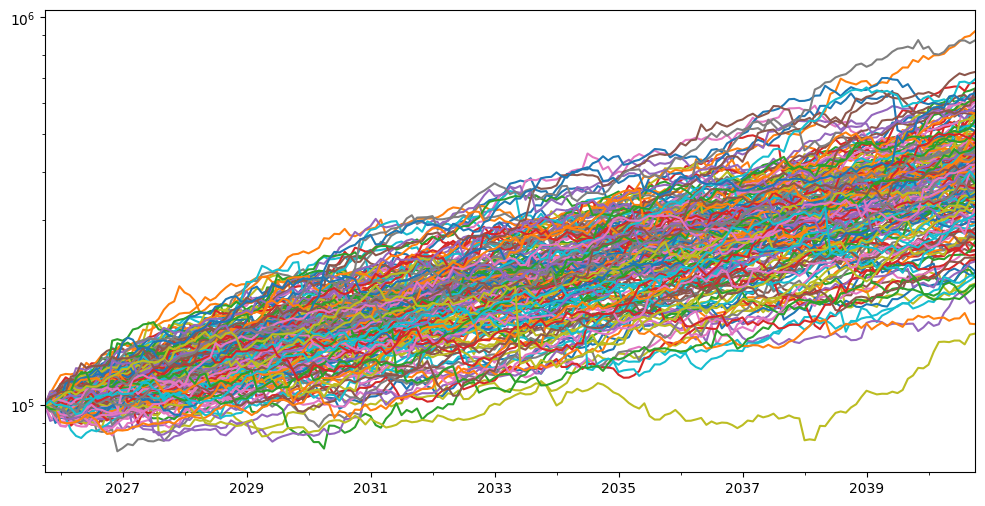

In [20]:
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")  # log scale Y-axis

Let's see which CAGR corresponds to the 5th percentile, a pessimistic scenario.

In [21]:
pf.dcf.mc.percentile_distribution_cagr(percentiles=[5])

{5: np.float64(0.05221176551356489)}

At the same percentile, we can also look at the expected portfolio value at the end of the forecast horizon.

In [22]:
df = pf.dcf.monte_carlo_wealth(discounting="fv")  # future value of wealth distribution (without discounting)
df.iloc[-1, :].quantile(5 / 100)  # 5th percentile of wealth after 15 years

np.float64(202722.97549916658)

Now let's consider a strategy with regular portfolio withdrawals.

In [23]:
pf.dcf.cashflow_parameters.frequency = "month"  # withdrawals will occur monthly
pf.dcf.cashflow_parameters.amount = -1000  # monthly withdrawal amount (a negative value means a withdrawal)
pf.dcf.cashflow_parameters

Strategy name                        fixed_amount
Portfolio symbol                portfolio_2031.PF
Cash flow initial investment               100000
Cash flow frequency                         month
Cash flow strategy                   fixed_amount
Cash flow amount                            -1000
Cash flow indexation                      0.02551
dtype: object

For portfolios with withdrawals, often called retirement portfolios, it is common to make forecasts for 25 years or longer. However, to evaluate what percentile of portfolios survives for 25 years, it is better to build the forecast with some extra margin. In this case, we will choose a 30-year Monte Carlo horizon. Then we can say with confidence what percentage of scenarios survives for 25 years. To do that, let us change the Monte Carlo settings.

In [24]:
pf.dcf.mc.period = 30  # forecasting period (years)

Now we can look at the forecast for the portfolio balance, including withdrawals.

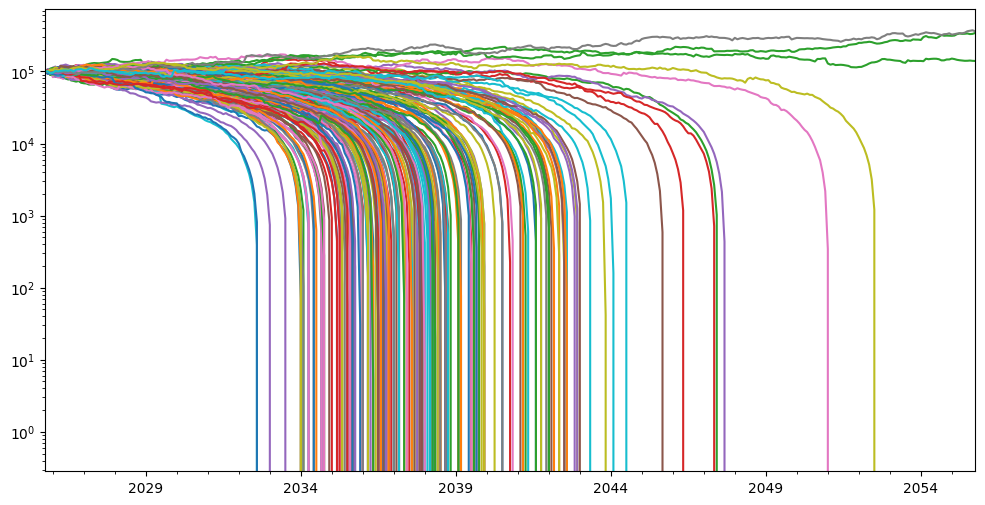

In [25]:
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")  # log scale Y-axis

Most random scenarios depleted the portfolio before the end of the selected period. This happens because the regular withdrawals are too large. With a starting capital of 100,000, a withdrawal of 1,000 per month corresponds to 12% in the first year.

The `find_the_largest_withdrawals_size` method can automatically find the maximum withdrawal amount that keeps the portfolio balance positive over a given horizon for a selected percentile. Let us try to find the maximum withdrawal amount for a 25-year horizon. With the `withdrawals_range=(0, 0.12)` parameter, we can significantly narrow the solution search range, because we have already tested 12% withdrawals and seen that they are too large.

In [26]:
result = pf.dcf.find_the_largest_withdrawals_size(
    goal="survival_period",  # optimization target: the maximum withdrawal amount that keeps the portfolio balance above zero for the required number of years
    percentile=5,
)

2026-03-28 21:05:01,974 - INFO - Iteration 0: error_rel=0.960, gradient=0.000
2026-03-28 21:05:12,941 - INFO - Iteration 1: error_rel=0.924, gradient=-0.036
2026-03-28 21:05:23,812 - INFO - Iteration 2: error_rel=0.844, gradient=-0.080
2026-03-28 21:05:34,712 - INFO - Iteration 3: error_rel=0.676, gradient=-0.168
2026-03-28 21:05:45,544 - INFO - Iteration 4: error_rel=0.200, gradient=-0.476
2026-03-28 21:05:56,408 - INFO - Iteration 5: error_rel=0.200, gradient=-0.000
2026-03-28 21:06:07,362 - INFO - Iteration 6: error_rel=0.200, gradient=0.000
2026-03-28 21:06:18,224 - INFO - Iteration 7: error_rel=0.012, gradient=-0.188
2026-03-28 21:06:18,224 - INFO - Solution found: -455.73 or 5.47% after 8 steps.


The result can be viewed in absolute or relative terms.

In [27]:
result.withdrawal_abs

-455.7291666666667

In [28]:
result.withdrawal_rel

0.0546875

If no solution is found, you can still inspect intermediate attempts in `result.solutions`.

In [29]:
result.solutions

,withdrawal_abs,withdrawal_rel,error_rel,error_rel_change
0,-8333.333333,1.0,0.96,0
1,-4166.666667,0.5,0.924,-0.036
2,-2083.333333,0.25,0.8442,-0.0798
3,-1041.666667,0.125,0.6762,-0.168
4,-520.833333,0.0625,0.2004,-0.4758
5,-260.416667,0.03125,0.2,-0.0004
6,-390.625,0.046875,0.2,0.0
7,-455.729167,0.054688,0.0124,-0.1876


The last step is to verify that the withdrawal amount found by the optimization really keeps the portfolio alive for 25 years.

In [30]:
pf.dcf.cashflow_parameters.amount = result.withdrawal_abs  # optimal monthly withdrawal amount found by the optimization

Let us plot the portfolio balance for random Monte Carlo scenarios.

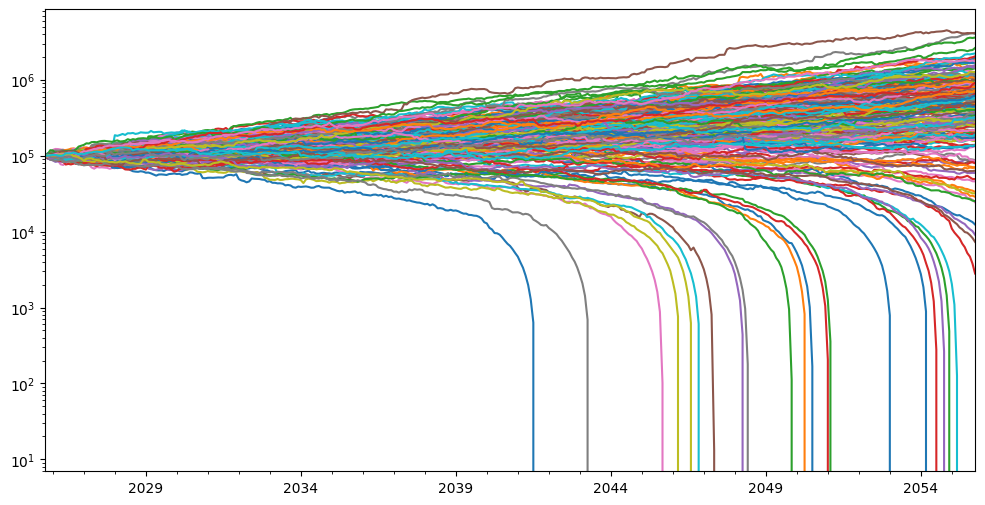

In [31]:
pf.dcf.plot_forecast_monte_carlo(backtest=False)
plt.yscale("log")  # log scale Y-axis

The Monte Carlo forecast horizon was chosen with extra margin (30 years). Therefore, we need to calculate the date 25 years after the strategy start date (`first_date`).

In [32]:
target_date = pf.first_date.to_period("M") + 25 * 12  # date 25 years after the start of the period

In [33]:
df = pf.dcf.monte_carlo_wealth(discounting="pv")
df.loc[target_date].quantile(5 / 100)  # 5th percentile of present value of wealth at target date

np.float64(73793.00589168306)

Now the withdrawal amount has been adjusted downward. Even in a pessimistic scenario, the portfolio survival period is longer than 25 years.

## Using historical data

If the available history is long enough, backtesting can provide a lot of useful information about the strategy properties.  
For example, let us look at the statistics for major drawdowns.

In [34]:
pf.drawdowns.nsmallest(10)

date
2009-02   -0.258226
2009-03   -0.225951
2009-01   -0.213814
2008-11   -0.209143
2008-10   -0.201033
2009-04   -0.188487
2022-09   -0.185789
2008-12   -0.178086
2022-10   -0.158310
2009-06   -0.157434
Freq: M, Name: portfolio_2031.PF, dtype: float64

The depth of drawdowns is only one part of the story. Recovery time shows how long the strategy stayed below its previous peak.


In [43]:
pf.recovery_period.nlargest(10) / 12

date
2010-03    2.416667
2023-11    1.916667
2016-02    0.750000
2011-12    0.666667
2018-07    0.500000
2005-05    0.416667
2016-12    0.416667
2019-01    0.416667
2010-08    0.333333
2006-07    0.250000
Freq: M, Name: portfolio_2031.PF, dtype: float64

The probability of getting a negative result (`score=0`) after 1 year, based on the historical distribution of strategy outcomes.

In [45]:
pf.percentile_inverse_cagr(years=1, score=0)

np.float64(12.863070539419088)

Rolling historical CAGR percentiles help us see how the range of outcomes changes with the investment horizon.  
The table below shows the 1st, 50th, and 99th percentiles of CAGR for rolling periods from 1 to 10 years.  
The main pattern is that the distribution becomes narrower as the horizon gets longer: the 1st percentile moves up, the 99th percentile moves down, and both tails get closer to the 50th percentile.

In [48]:
pf.percentile_cagr(years=10, percentiles=[1, 50, 99])

,1,50,99
years,,,
1,-0.196984,0.090800,0.267956
2,-0.075687,0.082821,0.204348
3,-0.019247,0.074416,0.167960
4,0.006616,0.073972,0.133521
5,0.043845,0.075349,0.123561
6,0.054314,0.076014,0.118953
7,0.060332,0.077478,0.108413
8,0.056283,0.077677,0.102405
9,0.057294,0.076319,0.103685


The chart below makes the same effect easier to see. 
It shows that the probability of a negative result declines as the investment horizon increases because the lower tail of the CAGR distribution moves closer to positive long-term outcomes.

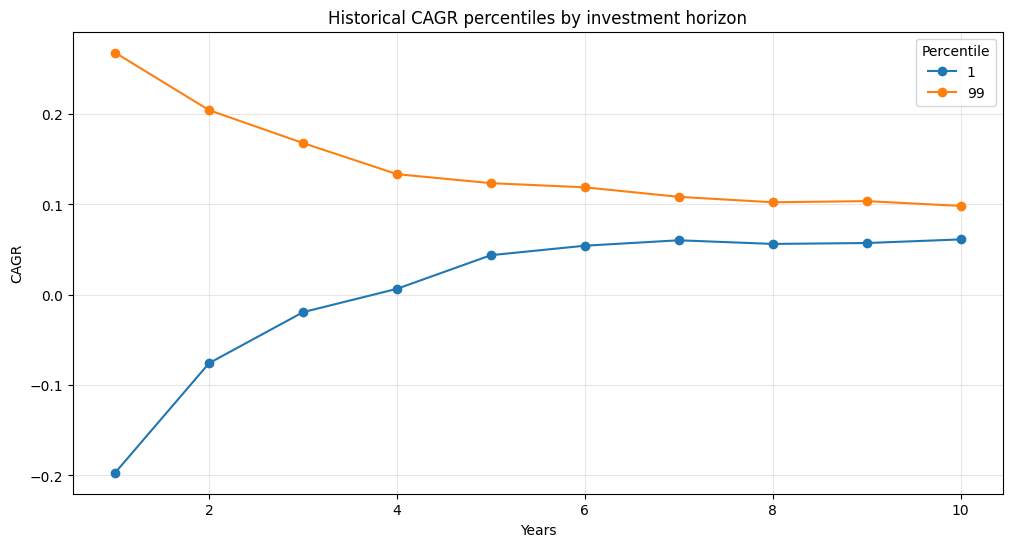

In [49]:
historical_cagr_percentiles = pf.percentile_cagr(years=10, percentiles=[1, 50, 99])
ax = historical_cagr_percentiles[[1, 99]].plot(marker="o")
ax.set_title("Historical CAGR percentiles by investment horizon")
ax.set_xlabel("Years")
ax.set_ylabel("CAGR")
ax.grid(True, alpha=0.3)
ax.legend(title="Percentile")
plt.show()

Historic `VaR` and `CVaR` provide another way to evaluate downside risk using realized rolling returns.  
In the examples below, `time_frame=12` means rolling 12-month returns, and `level=1` means we focus on the worst 1% of historical observations.  
`VaR` shows the loss threshold at that percentile, while `CVaR` shows the average loss inside that worst tail and is therefore usually more conservative.

In [50]:
pf.get_var_historic(time_frame=12, level=1)

np.float64(0.1969837716988523)

In [51]:
pf.get_cvar_historic(time_frame=12, level=1)

np.float64(0.2111871564724761)

Historical distributions are useful for intuition, but they are usually less reliable for forward-looking forecasts than Monte Carlo methods.  
The main limitation is that future market regimes, shocks, and cross-asset relationships may differ substantially from what we observed in the past.  
Because of that, historical backtesting should be treated as a reference point, while Monte Carlo modeling is usually a better tool for testing a wider range of plausible future scenarios.